# 1 试验

> **图 1.4** 针对不同目标的最优实验设计（实心圆点）。

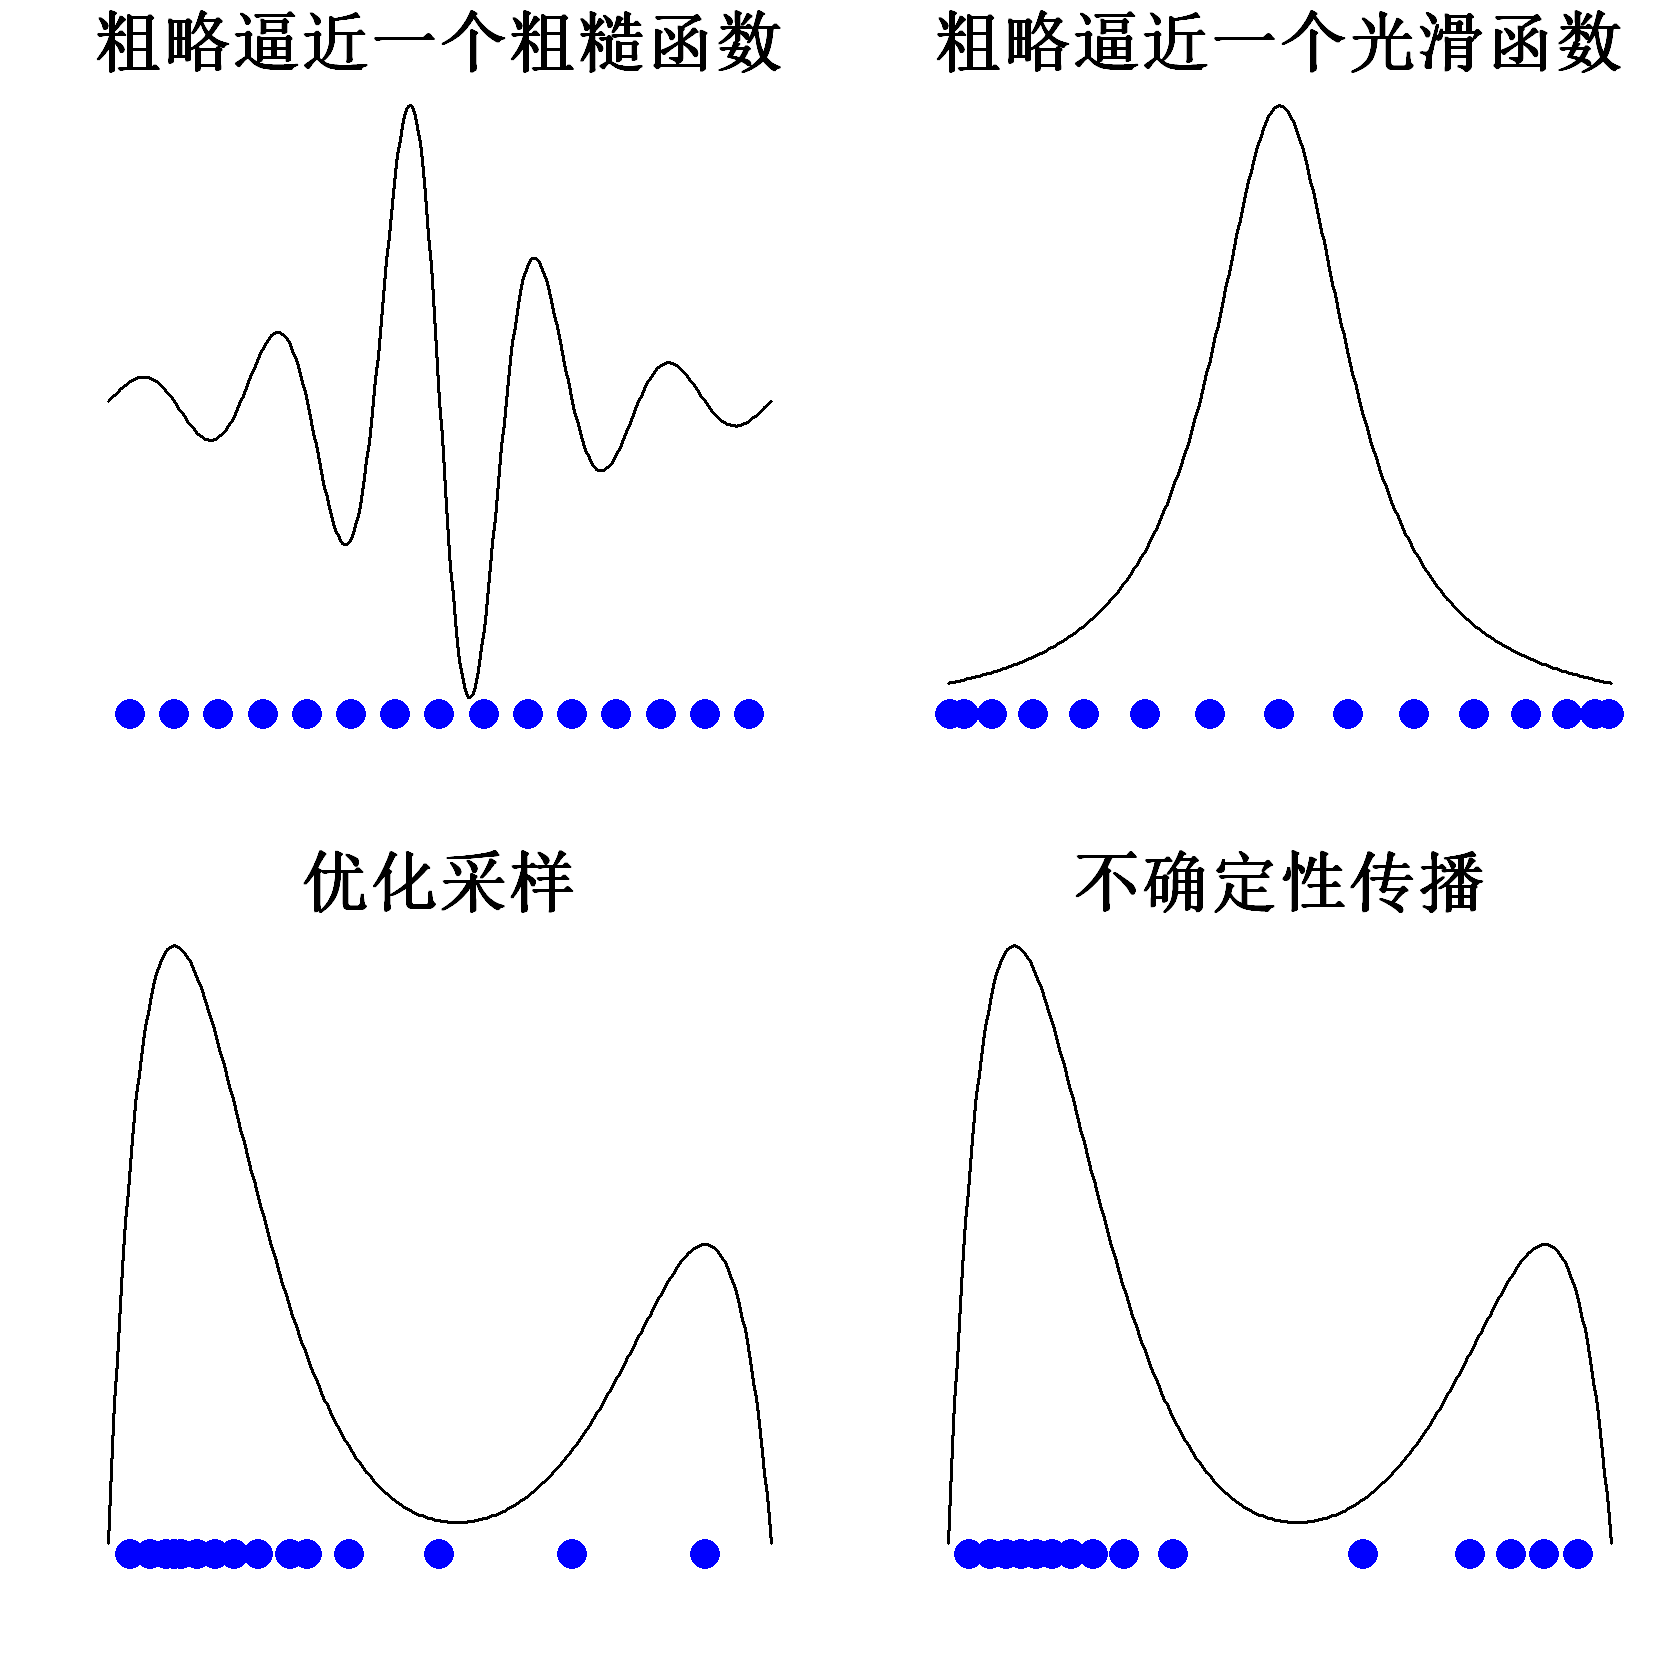

In [1]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/1.4-plot.RData")){
  x=seq(0,1,length=301) # 301x1
  n=15
  D1=((1:n)-.5)/n # 15x1
  y1=sin(10*pi*x)/(1+64*(x-.5)^2) # 301x1
  D2=qbeta(((1:n)-.5)/n,.5,.5) # 15x1
  y2=1/(1+64*(x-.5)^2) # 301x1
  n1=n*2/3; n2=n/3
  D0=((1:n2)-.5)/n2
  D3=c(D0,qbeta(((1:n1)-.5)/n1,2,10)) # 15x1
  y3=2/3*dbeta(x,2,10)+1/3*dbeta(x,10,2) # 301x1
  set.seed(1)
  x0=rbeta(1000*n1,2,10)
  x0=c(x0,rbeta(1000*n2,10,2))
  library(support)
  D4=sp(n,1,dist.samp=cbind(x0))$sp # 15x1
  y4=2/3*dbeta(x,2,10)+1/3*dbeta(x,10,2) # 301x1
  save(D1,D2,D3,D4,x,y1,y2,y3,y4,file="data/1.4-plot.RData")
}

load("data/1.4-plot.RData")

options(repr.plot.width=14,repr.plot.height=14)
par(mfrow=c(2,2))
plot(x,y1,type="l",axes=FALSE,xlab="",ylab="",lwd=3,ylim=c(min(y1)-.05,max(y1)),main="粗略逼近一个粗糙函数",cex.main=4)
points(cbind(D1,min(y1)-.05),pch=16,cex=4,col="blue")
plot(x,y2,type="l",axes=FALSE,xlab="",ylab="",lwd=3,ylim=c(min(y2)-.05,max(y2)),main="粗略逼近一个光滑函数",cex.main=4)
points(cbind(D2,min(y2)-.05),pch=16,cex=4,col="blue")
plot(x,y3,type="l",axes=FALSE,xlab="",ylab="",lwd=3,ylim=c(min(y3)-.05,max(y3)),main="优化采样",cex.main=4)
points(cbind(D3,min(y3)-.05),pch=16,cex=4,col="blue")
plot(x,y4,type="l",axes=FALSE,xlab="",ylab="",lwd=3,ylim=c(min(y4)-.05,max(y4)),main="不确定性传播",cex.main=4)
points(cbind(D4,min(y4)-.05),pch=16,cex=4,col="blue")

> **图 1.5** 线性回归与高斯过程回归的对比。

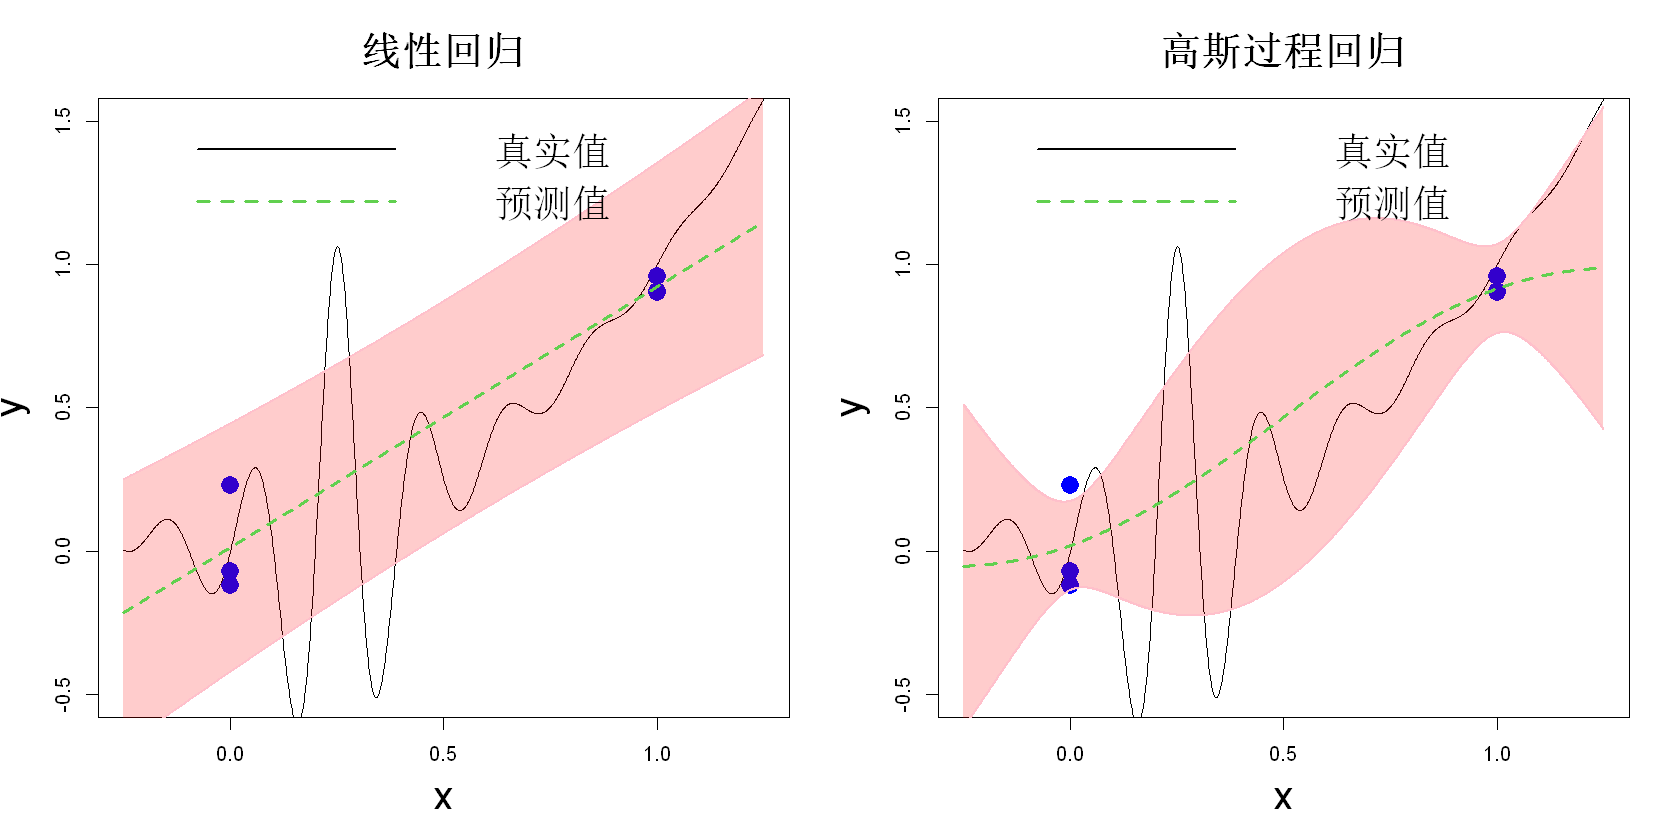

In [2]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/1.5-plot.RData")){
  set.seed(7)
  n=6
  x=rep(c(0,1),c(n/2,n/2)) # 6x1
  f=function(x) sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
  y=f(x)+.1*rnorm(n) # 6x1
  l=-.25; u=1.25
  test=seq(l,u,.001) # 1501x1
  truey=f(test) # 1501x1
  a.lm=lm(y~x)
  pred1=predict.lm(a.lm,newdata=data.frame(x=test),interval="prediction")
  mean1=pred1[,1]; low1=pred1[,2]; up1=pred1[,3] # 1501x1
  library(rkriging)
  a.gp=Fit.Kriging(x,y,interpolation=FALSE,fit=TRUE,model="OK",kernel.parameters=list(type="Gaussian"))
  pred2=Predict.Kriging(a.gp,test)
  mean2=pred2$mean; low2=pred2$mean-2*pred2$sd; up2=pred2$mean+2*pred2$sd # 1501x1
  save(x,y,test,truey,mean1,low1,up1,mean2,low2,up2,file="data/1.5-plot.RData")
}

load("data/1.5-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
l=-.25; u=1.25
plot(test,truey,type="l",xlim=c(l,u),ylim=c(-.5,1.5),main="线性回归",xlab="x",ylab="y",cex.main=2,cex.lab=2)
points(x,y,pch=16,col="blue",cex=2)
lines(test,mean1,col=3,lwd=3,lty=2)
polygon(c(test,rev(test)),c(low1,rev(up1)),col=adjustcolor("red",0.2),border="NA",lwd=2)
lines(test,low1,lwd=2,col="pink")
lines(test,up1,lwd=2,col="pink")
lines(test,mean1,col=3,lwd=3,lty=2)
legend("topleft",legend=c("真实值","预测值"),lty=c(1,2),col=c(1,3),lwd=c(2,3),bty="n",cex=2)

plot(test,truey,type="l",xlim=c(l,u),ylim=c(-.5,1.5),main="高斯过程回归",xlab="x",ylab="y",cex.main=2,cex.lab=2)
points(x,y,pch=16,col="blue",cex=2)
lines(test,mean2,col=3,lwd=3,lty=2)
polygon(c(test,rev(test)),c(low2,rev(up2)),col=adjustcolor("red",0.2),border="NA",lwd=2)
lines(test,low2,lwd=2,col="pink")
lines(test,up2,lwd=2,col="pink")
lines(test,mean2,col=3,lwd=3,lty=2)
legend("topleft",legend=c("真实值","预测值"),lty=c(1,2),col=c(1,3),lwd=c(2,3),bty="n",cex=2)
par(mfrow=c(1,1))